In [11]:
import sys
print(sys.version)

import numpy as np
import pandas as pd
import os
import math
import matplotlib.pyplot as plt
import networkx as nx
from matplotlib.patches import Patch
from tqdm import tqdm
from sklearn.cluster import DBSCAN, KMeans
from sklearn.manifold import TSNE
from scipy.spatial.distance import cdist
from collections import Counter


RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

3.14.2 (main, Dec  5 2025, 16:49:16) [Clang 17.0.0 (clang-1700.6.3.2)]


In [12]:
import os
import pandas as pd

def load_common_data(folder_path, min_files=10, encoding="latin1", print_progress=False):
    file_columns = {}

    # --- Step 1: Read headers safely ---
    for file in os.listdir(folder_path):
        if file.endswith(".csv"):
            path = os.path.join(folder_path, file)
            try:
                df = pd.read_csv(path, nrows=0, encoding=encoding)
                file_columns[file] = set(df.columns)
            except Exception as e:
                print(f"⚠ Skipping {file} during scan: {e}")

    if len(file_columns) < min_files:
        raise ValueError(f"Not enough readable files. Found {len(file_columns)}")

    # --- Step 2: Start with file that has the most columns ---
    sorted_files = sorted(file_columns.items(), key=lambda x: len(x[1]), reverse=True)

    selected_files = [sorted_files[0][0]]
    current_common = set(sorted_files[0][1])

    if print_progress:
        print(f"\n Starting with: {os.path.splitext(selected_files[0])[0]} ({len(current_common)} cols)")

    remaining_files = {f: cols for f, cols in sorted_files[1:]}

    # --- Step 3: Greedily add files that maximize remaining common columns ---
    while len(selected_files) < min_files and remaining_files:
        best_file = None
        best_intersection = set()

        for f, cols in remaining_files.items():
            intersection = current_common.intersection(cols)

            if len(intersection) > len(best_intersection):
                best_file = f
                best_intersection = intersection

        if best_file is None or len(best_intersection) == 0:
            print("⚠ No more compatible files can be added without losing all columns.")
            break

        selected_files.append(best_file)
        current_common = best_intersection

        if print_progress:
            print(f" + Added: {os.path.splitext(best_file)[0]} → {len(current_common)} common cols")

        del remaining_files[best_file]

    # --- Final report ---
    if print_progress:
        print(f"\n Final selected {len(selected_files)} files:")
    for f in selected_files:
        if print_progress:
            print(f" - {os.path.splitext(f)[0]} ({len(file_columns[f])} cols)")

    if print_progress:
        print(f"\n Final shared columns: {len(current_common)}")
        print(sorted(current_common))

    # --- Step 4: Load data ---
    dataframes = []

    for file in selected_files:
        path = os.path.join(folder_path, file)
        try:
            df = pd.read_csv(path, usecols=lambda c: c in current_common, encoding=encoding)

            season = os.path.splitext(file)[0]
            df["Season"] = season

            dataframes.append(df)
        except Exception as e:
            print(f"⚠ Skipping {file} during load: {e}")

    final_df = pd.concat(dataframes, ignore_index=True)

    return final_df, selected_files, list(current_common)

/var/folders/xd/8bcf5_6s4n7dsnwblqcqlthw0000gn/T/ipykernel_32834/1591882967.py:75: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["Season"] = season


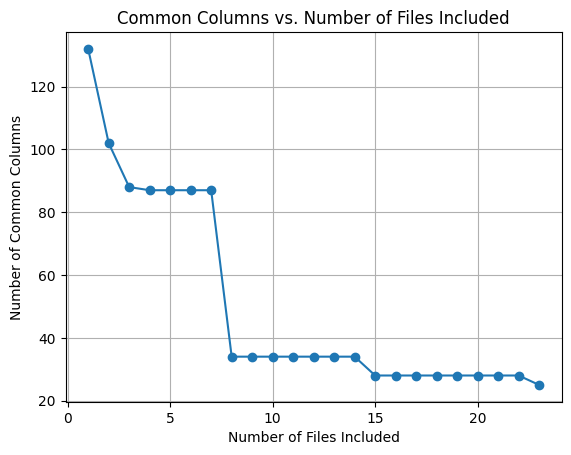

In [13]:
dataPath = "Data"
final_df, num_cols = [], []
for i in range(1, 24):
    df, _, cols = load_common_data(dataPath, min_files=i)
    final_df.append(df)
    num_cols.append(len(cols))    
plt.plot(range(1, 24), num_cols, marker='o')
plt.xlabel('Number of Files Included')
plt.ylabel('Number of Common Columns')
plt.title('Common Columns vs. Number of Files Included')
plt.grid()
plt.show()



## Multi-Season Dataset Construction (Greedy Alignment)

A greedy approach was used to build a consistent dataset across multiple football seasons.

The process starts with the season containing the most columns, then iteratively adds seasons that preserve the largest possible overlap of shared columns. At each step, the set of common columns is updated to ensure all selected seasons remain compatible.

After selecting the final group of seasons, only the columns shared across all of them are kept, and each season is loaded into a single combined DataFrame.

This ensures a consistent feature set across seasons while maximizing the number of usable datasets included.

We have chosen to include 7 seasons in our our pattern mining analysis, which provides a good balance between data richness and consistency.

In [14]:
def compute_streak(results):
        """
        Helper function
        Computes the current winning/losing streak based on a list of past results.
        A positive streak indicates consecutive wins, while a negative streak indicates consecutive losses.
        Parameters:
            - results: List of past results ('W', 'D', 'L')
        Returns:
            - Integer representing the current streak (positive for wins, negative for losses)
        """
        streak = 0
        for r in reversed(results):
            if r == 'W':
                if streak < 0: break
                streak += 1
            elif r == 'L':
                if streak > 0: break
                streak -= 1
            else:
                break
        return streak

def add_form_features(df, date_col='Date', home_col='HomeTeam', away_col='AwayTeam',
                      ftr_col='FTR', fthg_col='FTHG', ftag_col='FTAG'):
    """
    Adds form-related features to the DataFrame:
    - home_streak: Current winning/losing streak for the home team
    - away_streak: Current winning/losing streak for the away team
    - home_goals_l5: Total goals scored by the home team in the last 5 matches
    - away_goals_l5: Total goals scored by the away team in the last 5 matches
    Parameters:
        - df: Input DataFrame containing match data
        - date_col: Column name for match date
        - home_col: Column name for home team
        - away_col: Column name for away team
        - ftr_col: Column name for full-time result (H/D/A)
        - fthg_col: Column name for full-time home goals
        - ftag_col: Column name for full-time away goals
    Returns:
        - DataFrame with added form features
    """
    df = df.copy()
    df[date_col] = pd.to_datetime(df[date_col], format='mixed', dayfirst=True)  # <-- fix
    df = df.sort_values(date_col).reset_index(drop=True)

    home_records = df[[date_col, home_col, fthg_col, ftr_col]].copy()
    home_records.columns = ['date', 'team', 'goals', 'ftr']
    home_records['result'] = home_records['ftr'].map({'H': 'W', 'D': 'D', 'A': 'L'})

    away_records = df[[date_col, away_col, ftag_col, ftr_col]].copy()
    away_records.columns = ['date', 'team', 'goals', 'ftr']
    away_records['result'] = away_records['ftr'].map({'H': 'L', 'D': 'D', 'A': 'W'})

    history = pd.concat([home_records, away_records], ignore_index=True)
    history = history.sort_values('date').reset_index(drop=True)

    team_history = {}
    home_streaks, away_streaks = [], []
    home_goals_l5, away_goals_l5 = [], []

    for _, row in df.iterrows():
        match_date = row[date_col]
        for side in ['home', 'away']:
            team = row[home_col] if side == 'home' else row[away_col]
            if team not in team_history:
                team_history[team] = history[history['team'] == team].sort_values('date')
            th = team_history[team]
            past = th[th['date'] < match_date]
            if len(past) == 0:
                streak, goals_l5 = 0, 0
            else:
                streak = compute_streak(past['result'].tolist())
                goals_l5 = past['goals'].iloc[-5:].sum()
            if side == 'home':
                home_streaks.append(streak)
                home_goals_l5.append(goals_l5)
            else:
                away_streaks.append(streak)
                away_goals_l5.append(goals_l5)

    df['home_streak']   = home_streaks
    df['away_streak']   = away_streaks
    df['home_goals_l5'] = home_goals_l5
    df['away_goals_l5'] = away_goals_l5

    return df

In [15]:
data, selected_files, common_cols = load_common_data(dataPath, min_files=20)
print(f"Selected files: {sorted(selected_files)}")
print(f"Number of common columns: {len(common_cols)}")
data = add_form_features(data)
print(data[['Date', 'HomeTeam', 'AwayTeam', 'FTR',
            'home_streak', 'away_streak',
            'home_goals_l5', 'away_goals_l5']])
data

Selected files: ['20062007premierleague.csv', '20072008premierleague.csv', '20082009premierleague.csv', '20092010premierleague.csv', '20102011premierleague.csv', '20112012premierleague.csv', '20122013premierleague.csv', '20132014premierleague.csv', '20142015premierleague.csv', '20152016premierleague.csv', '20162017premierleague.csv', '20172018premierleague.csv', '20182019premierleague.csv', '20192020premierleague.csv', '20202021premierleague.csv', '20212022premierleague.csv', '20222023premierleague.csv', '20232024premierleague.csv', '20242025premierleague.csv', '20252026premierleague.csv']
Number of common columns: 28
           Date       HomeTeam     AwayTeam  FTR  home_streak  away_streak  \
0    2006-08-19        Arsenal  Aston Villa    D            0            0   
1    2006-08-19         Bolton    Tottenham    H            0            0   
2    2006-08-19        Everton      Watford    H            0            0   
3    2006-08-19      Newcastle        Wigan    H            0 

,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,HTR,Referee,...,B365D,B365A,BWH,BWD,BWA,Season,home_streak,away_streak,home_goals_l5,away_goals_l5
0,2006-08-19,Arsenal,Aston Villa,1.0,1.0,D,0.0,0.0,D,G Poll,...,4.5,13.00,1.25,5.00,10.00,20062007premierleague,0,0,0.0,0.0
1,2006-08-19,Bolton,Tottenham,2.0,0.0,H,2.0,0.0,H,P Dowd,...,3.2,2.60,2.60,3.10,2.55,20062007premierleague,0,0,0.0,0.0
2,2006-08-19,Everton,Watford,2.0,1.0,H,1.0,0.0,H,P Walton,...,3.4,5.50,1.65,3.40,5.00,20062007premierleague,0,0,0.0,0.0
3,2006-08-19,Newcastle,Wigan,2.0,1.0,H,1.0,0.0,H,M Atkinson,...,3.5,4.75,1.70,3.35,4.70,20062007premierleague,0,0,0.0,0.0
4,2006-08-19,Portsmouth,Blackburn,3.0,0.0,H,1.0,0.0,H,A Wiley,...,3.1,3.10,2.45,3.10,2.70,20062007premierleague,0,0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7476,2026-02-11,Sunderland,Liverpool,0.0,1.0,A,0.0,0.0,D,C Kavanagh,...,3.8,1.73,4.40,3.80,1.77,20252026premierleague,-1,-1,6.0,8.0
7477,2026-02-11,Aston Villa,Brighton,1.0,0.0,H,0.0,0.0,D,P Bankes,...,3.7,3.80,1.90,3.75,3.75,20252026premierleague,0,-1,3.0,4.0
7478,2026-02-11,Nott'm Forest,Wolves,0.0,0.0,D,0.0,0.0,D,T Robinson,...,3.8,5.00,1.71,3.80,4.80,20252026premierleague,-1,-3,6.0,2.0
7479,2026-02-12,Brentford,Arsenal,1.0,1.0,D,0.0,0.0,D,J Brooks,...,3.9,1.70,4.80,3.80,1.70,20252026premierleague,2,2,7.0,9.0


In [16]:
# Define bookmaker prefixes and outcome suffixes
prefixes = ["B365", "BW", "PS"]
suffixes = ["A", "H", "D"]
valid_cols = {p + s for p in prefixes for s in suffixes}

# relevant_cols = odds columns that exist in common_cols + Referee
relevant_cols = [c for c in common_cols if c in valid_cols] + ['Referee']

In [17]:
def compute_quantile_bins(data, relevant_cols, suffixes=["H", "D", "A"], n_bins=5):
    """
    Compute quantile-based bin edges for each outcome type (H, D, A),
    pooling odds across all bookmakers for that outcome type.
    
    Returns a dict like: {'H': (bins, labels), 'D': (bins, labels), 'A': (bins, labels)}
    """
    bin_specs = {}
    
    for suffix in suffixes:
        # Pool all odds for this outcome across all bookmakers
        cols_for_suffix = [c for c in relevant_cols if c.endswith(suffix)]
        pooled = pd.concat([data[c].dropna() for c in cols_for_suffix])
        
        # Compute quantile edges (0%, 20%, 40%, 60%, 80%, 100%)
        quantiles = np.linspace(0, 1, n_bins + 1)
        edges = pooled.quantile(quantiles).values
        
        # Ensure strictly increasing edges (can have ties at extremes)
        edges = np.unique(edges)
        edges[0] = 0       # open lower bound
        edges[-1] = np.inf # open upper bound
        
        # Labels like "1.42–1.75", "1.75–2.10", etc.
        labels = [
            f"{edges[i]:.2f}–{edges[i+1]:.2f}".replace("inf", "∞")
            for i in range(len(edges) - 1)
        ]
        
        bin_specs[suffix] = (edges, labels)
        print(f"[{suffix}] edges: {np.round(edges, 3)}  →  {len(labels)} bins")
    
    return bin_specs


def discretize_odds_quantile(series, bin_specs):
    """
    Discretize a single odds column using precomputed quantile bin specs.
    Detects outcome type from the column name's last character.
    """
    suffix = series.name[-1]  # 'H', 'D', or 'A'
    bins, labels = bin_specs[suffix]
    return pd.cut(series, bins=bins, labels=labels)

def build_transactions(data, bin_specs):
    tx = pd.DataFrame()

    # Identity
    tx['HomeTeam'] = 'H=' + data['HomeTeam']
    tx['AwayTeam'] = 'A=' + data['AwayTeam']
    tx['Referee']  = 'Ref=' + data['Referee'].fillna('Unknown')
    tx['Season']   = 'S=' + data['Season']

    # Results
    tx['FTR'] = 'FTR=' + data['FTR']
    tx['HTR'] = 'HTR=' + data['HTR']

    # Goals
    tx['TotalGoals'] = pd.cut(data['FTHG'] + data['FTAG'],
                               bins=[-1,1,2,3,5,99],
                               labels=['goals_0-1','goals_2','goals_3','goals_4-5','goals_6+'])
    tx['TotalGoals'] = 'TG=' + tx['TotalGoals'].astype(str)

    # Odds bins (use your quantile bins)
    for suffix in ['H', 'D', 'A']:
        col = f'B365{suffix}'
        tx[col] = col + '=' + discretize_odds_quantile(
            data[col].rename(col), bin_specs).astype(str)

    # Cards
    tx['HomeYellow'] = 'HY=' + pd.cut(data['HY'], bins=[-1,1,3,99],
                                        labels=['low','mid','high']).astype(str)
    tx['AwayYellow'] = 'AY=' + pd.cut(data['AY'], bins=[-1,1,3,99],
                                        labels=['low','mid','high']).astype(str)

    # Over/under
    # tx['OU'] = 'OU_2.5=' + pd.cut(data['B365>2.5'], bins=[0, 1.7, 2.1, np.inf],
    #                             labels=['likely_over','even','likely_under']).astype(str)

    # Convert each row to a list of items (dropping NaNs)
    transactions = tx.apply(
        lambda row: [v for v in row.values if pd.notna(v) and 'nan' not in str(v)],
        axis=1
    ).tolist()

    return transactions

In [18]:
bin_specs = compute_quantile_bins(data, relevant_cols)
transactions = build_transactions(data, bin_specs)
print(transactions[0])

[H] edges: [0.   1.53 1.95 2.4  3.5   inf]  →  5 bins
[D] edges: [0.   3.3  3.5  3.75 4.5   inf]  →  5 bins
[A] edges: [0.   2.1  2.95 3.85 6.25  inf]  →  5 bins
['H=Arsenal', 'A=Aston Villa', 'Ref=G Poll', 'S=20062007premierleague', 'FTR=D', 'HTR=D', 'TG=goals_2', 'B365H=0.00–1.53', 'B365D=3.75–4.50', 'B365A=6.25–∞', 'HY=low', 'AY=mid']


In [19]:
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import fpgrowth, association_rules

te = TransactionEncoder()
te_array = te.fit_transform(transactions)
te_df = pd.DataFrame(te_array, columns=te.columns_)

frequent = fpgrowth(te_df, min_support=0.01, use_colnames=True)
rules = association_rules(frequent, metric="confidence", min_threshold=0.6)
rules = rules.sort_values("lift", ascending=False)

# Odds-derived features — useful as ANTECEDENTS (inputs/context)
antecedent_prefixes = ['home_streak', 'away_streak', 'home_goals_l5', 'away_goals_l5'] #['TG=', 'FTR=', 'HTR='] #['B365H=', 'B365D=', 'B365A=', 'OU_2.5=']

# Match outcome features — useful as CONSEQUENTS (things to predict)  
consequent_prefixes = ['B365H=', 'B365D=', 'B365A='] #['FTR=', 'HTR=']

# Identity features — useful as ANTECEDENTS only
identity_prefixes = ['H=', 'A=', 'Ref=', 'S=']

def all_start_with(itemset, prefixes):
    return all(any(item.startswith(p) for p in prefixes) for item in itemset)

input_prefixes  = antecedent_prefixes + identity_prefixes
output_prefixes = consequent_prefixes

interesting_rules = rules[
    (rules['support'] > 0.01) &
    (rules['confidence'] > 0.55) &
    (rules['lift'] > 1.25) &
    rules['antecedents'].apply(lambda x: all_start_with(x, input_prefixes)) &
    rules['consequents'].apply(lambda x: all_start_with(x, output_prefixes))
].sort_values(['lift', 'confidence'], ascending=[False, False])

print(f"{len(rules)} before filtering, {len(interesting_rules)} rules after filtering")

10610 before filtering, 26 rules after filtering


In [20]:
# --- Sort by lift, then confidence ---
sorted_rules = interesting_rules.sort_values(
    ['lift', 'confidence'], ascending=[False, False]
)

# --- Pretty print ---
print(f"{'='*80}")
print(f"  ALL RULES  |  {len(sorted_rules)} rules found")
print(f"{'='*80}")

for i, (_, row) in enumerate(sorted_rules.iterrows(), 1):
    ant = ', '.join(sorted(row['antecedents']))
    con = ', '.join(sorted(row['consequents']))
    print(f"\n#{i:03d}  {ant}")
    print(f"  →  {con}")
    print(f"     support={row['support']:.3f}  "
          f"confidence={row['confidence']:.3f}  "
          f"lift={row['lift']:.3f}  "
          f"leverage={row['leverage']:.3f}  "
          f"conviction={row['conviction']:.2f}   "
          f"Total matches: {row['support'] * len(te_df):.0f}")

  ALL RULES  |  26 rules found

#001  A=Man City
  →  B365A=0.00–2.10, B365H=3.50–∞
     support=0.033  confidence=0.668  lift=3.413  leverage=0.024  conviction=2.43   Total matches: 250

#002  A=Chelsea
  →  B365A=0.00–2.10, B365H=3.50–∞
     support=0.033  confidence=0.666  lift=3.400  leverage=0.023  conviction=2.41   Total matches: 249

#003  A=Man City
  →  B365H=3.50–∞
     support=0.034  confidence=0.671  lift=3.363  leverage=0.024  conviction=2.43   Total matches: 251

#004  A=Chelsea
  →  B365H=3.50–∞
     support=0.033  confidence=0.668  lift=3.349  leverage=0.023  conviction=2.41   Total matches: 250

#005  A=Chelsea
  →  B365A=0.00–2.10
     support=0.035  confidence=0.695  lift=3.332  leverage=0.024  conviction=2.60   Total matches: 260

#006  H=Liverpool
  →  B365A=6.25–∞, B365H=0.00–1.53
     support=0.032  confidence=0.650  lift=3.329  leverage=0.023  conviction=2.30   Total matches: 243

#007  H=Man City
  →  B365A=6.25–∞, B365H=0.00–1.53
     support=0.032  confidence

We want to see whether the bookmakers adjust odds based on recent performance of the teams. 
This is hard due to the fact that odds is much more sensitive to the teams playing than the actual form of the team. 
Maybe there is some way to normalize the form with who is playing.

Maybe we can find some other stuff. ask Davide 